In [2]:
import numpy as np
import xarray as xr
from minisom import MiniSom
import pandas as pd
from sklearn.preprocessing import RobustScaler
import pprint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib import colormaps as cm
from som_multivar_training import read_and_transform, build_scaler, train_som
import warnings
warnings.filterwarnings('ignore')

In [3]:
prefs= {'filename': '/home/z2034747/Research/Datasets/Combined/pwat_z500_td2m.nc',
        'vars': ['z500', 'pwat'], 'wlon': 220, 'elon': 305, 'nlat': 55, 'slat': 20, 
         'som_config': {'x': 3, 'y': 3, 'sigma': 1.5, 'random_seed': 42},
         'som_train': {'num_iteration': 20000, 'random_order': True, 'verbose': True}}

In [4]:
trained_som, trained_scaler, train_info, xr_data = train_som(prefs)

current model configuration
{'input_len': 36423, 'random_seed': 42, 'sigma': 1.5, 'x': 3, 'y': 3}
current training configuration
{'data': array([[-0.20787   , -0.23133911, -0.24382445, ..., -0.39776176,
        -0.19108878, -0.1742262 ],
       [-1.4184133 , -1.4353495 , -1.4344262 , ..., -1.1606435 ,
        -1.0643088 , -1.0463164 ],
       [ 0.2818785 ,  0.26043582,  0.24609436, ..., -1.0347401 ,
        -0.9122647 , -0.8908087 ],
       ...,
       [-0.37288073, -0.36255017, -0.34266713, ...,  0.16134287,
        -0.06155263, -0.45548353],
       [-0.9060967 , -0.880783  , -0.8457077 , ..., -0.27605513,
        -0.05695932, -0.07295413],
       [-0.7406267 , -0.7585039 , -0.7617178 , ..., -0.5390535 ,
        -0.5787782 , -0.5821934 ]], dtype=float32),
 'num_iteration': 20000,
 'random_order': True,
 'verbose': True}
 [ 20000 / 20000 ] 100% - 0:00:00 left 
 quantization error: 92.20592606121889


In [47]:
ds = xr_data

breaks = ds.sizes['lon'] * ds.sizes['lat']

win_map = trained_som.win_map(train_info['som_train']['data'])

node_keys = sorted(win_map.keys())

key1_avg_data = [
    np.reshape(
        trained_scaler.inverse_transform([np.mean(win_map[node], axis=0)])[0][:1 * breaks],
        (len(xr_data.lat), len(xr_data.lon))
    )
    for node in sorted(win_map.keys())
]

key2_avg_data = [
    np.reshape(
        trained_scaler.inverse_transform([np.mean(win_map[node], axis=0)])[0][1* breaks: 2* breaks],
        (len(xr_data.lat), len(xr_data.lon))
    )
    for node in sorted(win_map.keys())
]

key3_avg_data = [
    np.reshape(
        trained_scaler.inverse_transform([np.mean(win_map[node], axis=0)])[0][2* breaks: 3* breaks],
        (len(xr_data.lat), len(xr_data.lon))
    )
    for node in sorted(win_map.keys())
]

frequencies = trained_som.activation_response(train_info['som_train']['data']).flatten()

length, width = prefs['som_config']['x'], prefs['som_config']['y']

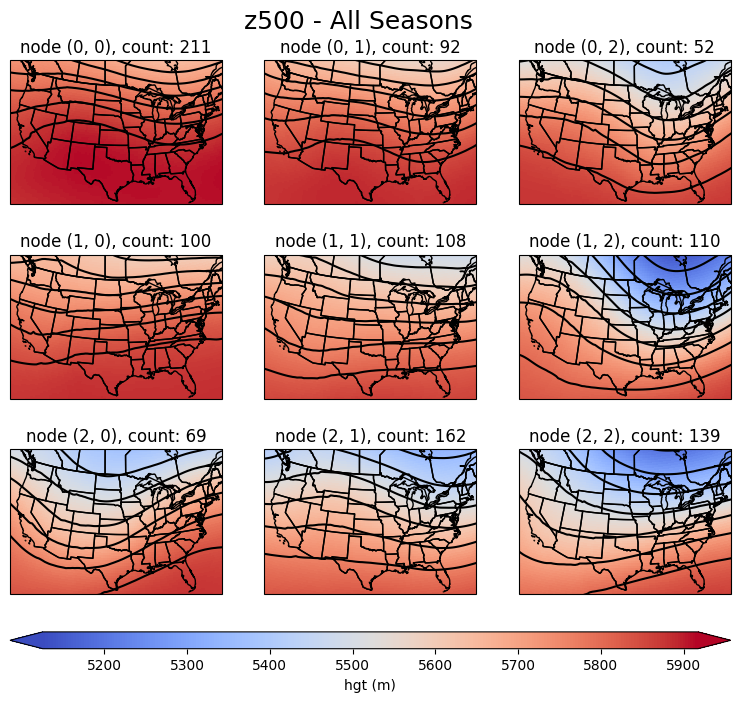

In [15]:
gs = GridSpec(nrows= length + 1, ncols= width, height_ratios=[1]*length + [0.1])
fig = plt.figure(figsize=(3.1 * length, 2.6 * width))
ax = [fig.add_subplot(gs[(x // length, x % width)], projection=ccrs.LambertConformal())
      for x in range(len(key1_avg_data))]
vmin = np.min(key1_avg_data)
vmax = np.max(key1_avg_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
for i, data in enumerate(key1_avg_data):
    ax[i].set_extent([xr_data.lon.values.min() - 340, xr_data.lon.values.max() - 380,
                      xr_data.lat.values.min() + 3, xr_data.lat.values.max() - 3])
    ax[i].add_feature(cfeature.BORDERS)
    ax[i].add_feature(cfeature.STATES)
    
    cf = ax[i].pcolormesh(xr_data.lon, xr_data.lat, data, cmap='coolwarm', norm= norm, transform=ccrs.PlateCarree())
    cn = ax[i].contour(xr_data.lon, xr_data.lat, data,  colors='k', transform=ccrs.PlateCarree())
    ax[i].set_title(f'node {node_keys[i]}, count: {int(frequencies[i])}')
    
    
cax = fig.add_subplot(gs[-1, :])    
fig.colorbar(cf, cax=cax, label='hgt (m)', extend= 'both', orientation='horizontal', aspect=0.8)
plt.suptitle('z500 - All Seasons', fontsize=18, y=0.93)
# plt.savefig('standard_anomalies.png', bbox_inches='tight')
plt.show()


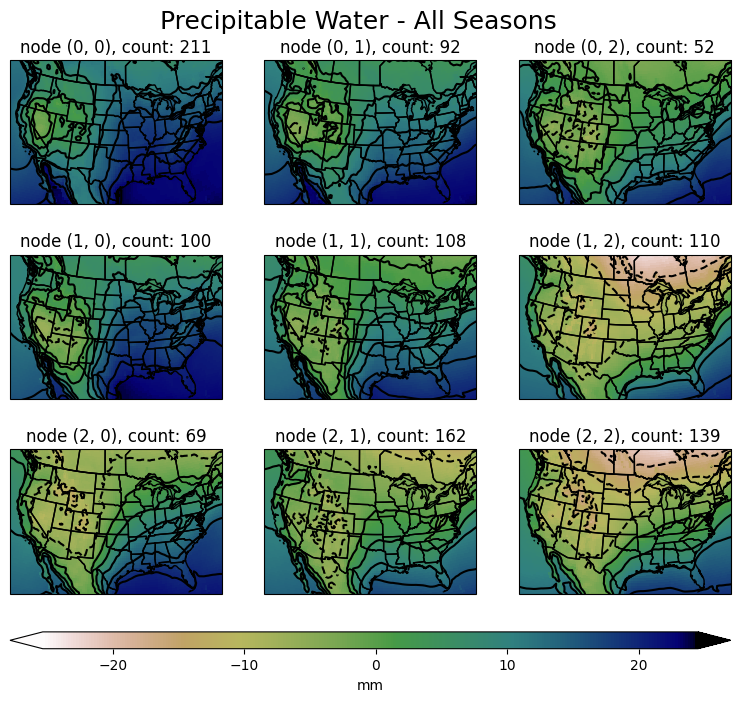

In [52]:
gs = GridSpec(nrows= length + 1, ncols= width, height_ratios=[1]*length + [0.1])
fig = plt.figure(figsize=(3.1 * length, 2.6 * width))
ax = [fig.add_subplot(gs[(x // length, x % width)], projection=ccrs.LambertConformal())
      for x in range(len(key2_avg_data))]
vmin = np.min(key2_avg_data)
vmax = np.max(key2_avg_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
for i, data in enumerate(key2_avg_data):
    ax[i].set_extent([xr_data.lon.values.min() - 340, xr_data.lon.values.max() - 380,
                      xr_data.lat.values.min() + 3, xr_data.lat.values.max() - 3])
    ax[i].add_feature(cfeature.BORDERS)
    ax[i].add_feature(cfeature.STATES)
    
    cf = ax[i].pcolormesh(xr_data.lon, xr_data.lat, data, cmap='gist_earth_r', norm= norm, transform=ccrs.PlateCarree())
    cn = ax[i].contour(xr_data.lon, xr_data.lat, data,  colors='k', transform=ccrs.PlateCarree())
    ax[i].set_title(f'node {node_keys[i]}, count: {int(frequencies[i])}')
    
    
cax = fig.add_subplot(gs[-1, :])    
fig.colorbar(cf, cax=cax, label='mm', extend= 'both', orientation='horizontal', aspect=0.8)
plt.suptitle('Precipitable Water - All Seasons', fontsize=18, y=0.93)
# plt.savefig('standard_anomalies.png', bbox_inches='tight')
plt.show()

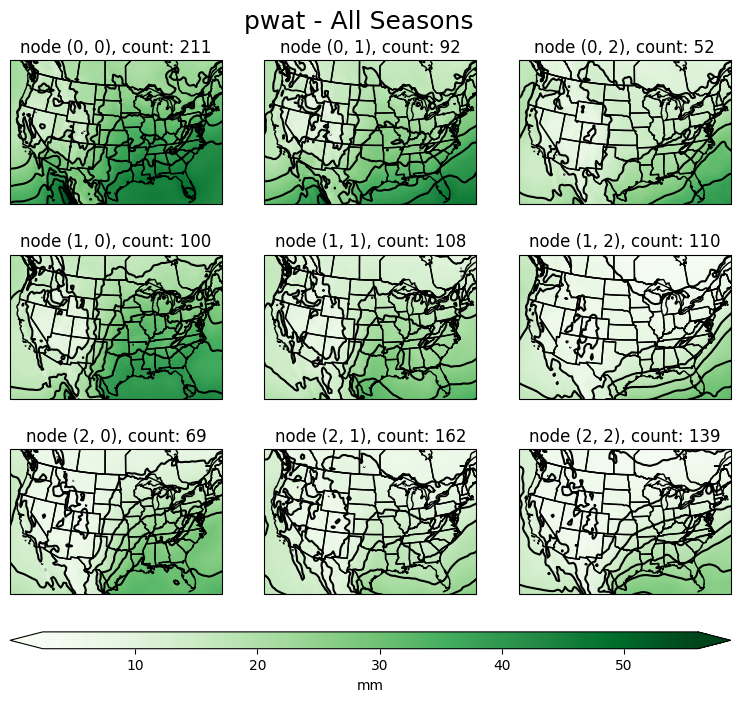

In [51]:
gs = GridSpec(nrows= length + 1, ncols= width, height_ratios=[1]*length + [0.1])
fig = plt.figure(figsize=(3.1 * length, 2.6 * width))
ax = [fig.add_subplot(gs[(x // length, x % width)], projection=ccrs.LambertConformal())
      for x in range(len(key3_avg_data))]
vmin = np.min(key3_avg_data)
vmax = np.max(key3_avg_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
for i, data in enumerate(key3_avg_data):
    ax[i].set_extent([xr_data.lon.values.min() - 340, xr_data.lon.values.max() - 380,
                      xr_data.lat.values.min() + 3, xr_data.lat.values.max() - 3])
    ax[i].add_feature(cfeature.BORDERS)
    ax[i].add_feature(cfeature.STATES)
    
    cf = ax[i].pcolormesh(xr_data.lon, xr_data.lat, data, cmap='Greens', norm= norm, transform=ccrs.PlateCarree())
    cn = ax[i].contour(xr_data.lon, xr_data.lat, data,  colors='k', transform=ccrs.PlateCarree())
    ax[i].set_title(f'node {node_keys[i]}, count: {int(frequencies[i])}')
    
    
cax = fig.add_subplot(gs[-1, :])    
fig.colorbar(cf, cax=cax, label='mm', extend= 'both', orientation='horizontal', aspect=0.8)
plt.suptitle('pwat - All Seasons', fontsize=18, y=0.93)
# plt.savefig('standard_anomalies.png', bbox_inches='tight')
plt.show()

In [25]:
xr_data.td2m.min()

<xarray.DataArray 'td2m' ()> Size: 8B
array(-44.17613602)

In [28]:
np.max(key1_avg_data)

5917.401813325443

In [29]:
xr_data

<xarray.Dataset> Size: 152MB
Dimensions:  (time: 1043, lat: 71, lon: 171)
Coordinates:
  * time     (time) datetime64[ns] 8kB 2000-01-05 2000-01-12 ... 2019-12-25
  * lat      (lat) float32 284B 55.0 54.5 54.0 53.5 53.0 ... 21.5 21.0 20.5 20.0
  * lon      (lon) float32 684B 220.0 220.5 221.0 221.5 ... 304.0 304.5 305.0
Data variables:
    z500     (time, lat, lon) float32 51MB 5.424e+03 5.423e+03 ... 5.859e+03
    td2m     (time, lat, lon) float32 51MB -1.034 -1.227 -1.449 ... 19.89 19.86
    pwat     (time, lat, lon) float32 51MB 8.574 7.938 7.5 ... 27.54 26.7 26.9

In [32]:
ds1 = xr.open_dataset('/home/scratch/GEFSv12/reforecasts/conus_subset/subset_vars_2000010500.nc')

In [33]:
ds1

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 180, lat: 71, lon: 171, ens: 11)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2000-01-05 ... 2000-02-08T18:00:00
  * lat         (lat) float32 284B 55.0 54.5 54.0 53.5 ... 21.5 21.0 20.5 20.0
  * lon         (lon) float32 684B 220.0 220.5 221.0 221.5 ... 304.0 304.5 305.0
Dimensions without coordinates: ens
Data variables: (12/26)
    u10         (ens, time, lat, lon) float32 96MB ...
    v10         (ens, time, lat, lon) float32 96MB ...
    t2m         (ens, time, lat, lon) float32 96MB ...
    td2m        (ens, time, lat, lon) float32 96MB ...
    cprec       (ens, time, lat, lon) float32 96MB ...
    prec        (ens, time, lat, lon) float32 96MB ...
    ...          ...
    sbcape_gfs  (ens, time, lat, lon) float32 96MB ...
    sbcin_gfs   (ens, time, lat, lon) float32 96MB ...
    mucape      (ens, time, lat, lon) float32 96MB ...
    mlcape      (ens, time, lat, lon) float32 96MB ...
    ulcape      (ens, time, lat, lon) float32 96MB ...
    mlcape3km   (ens, time, lat, lon) float32 96MB ...
Attributes:
    title:         Customized GEFSv12 Reforecasts
    grid:          0.5 degree CONUS subset
    author:        Dr. Victor Gensini
    author_email:  vgensini@niu.edu

In [37]:
for node in win_map.keys():
    print(len(win_map[node]))

110
139
162
108
100
92
211
69
52


In [46]:
len(win_map[(0, 0)][5])

36423

In [43]:
breaks * 3

36423

In [54]:
np.min(key3_avg_data)

2.410317566933827

In [57]:
np.min(xr_data.pwat)

<xarray.DataArray 'pwat' ()> Size: 8B
array(0.35795453)